In [1]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

import pandas as pd

In [2]:
def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # take the average
    results_avg = []

    for ids in id_groups:
        group = [id_result[_id] for _id in ids]
        param = np.array([r[0] for r in group])
        hyp_param = np.array([r[1] for r in group])
        val_scores = np.array([r[2] for r in group])
        test_scores = np.array([r[3] for r in group])
        avg_res = [
            np.nanmean(param, axis=0),
            np.nanmean(hyp_param, axis=0),
            np.nanmean(val_scores, axis=0),
            np.nanmean(test_scores, axis=0),
        ]

        results_avg.append(avg_res)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = [val_res[i] for i in (0, 2, 3)]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        print(ids)
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

In [26]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # ---------- grouping by (param, hyp_param) ----------
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = f"{result[param]}|{result[hyp_param]}"
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],  # scalar
            result[hyp_param],  # scalar
            result["val_score"][metric_idx],  # SCALAR
            result["test_score"][metric_idx],  # SCALAR
        ]

    id_groups = list(param_ids.values())

    # ---------- average over CV ----------
    results_avg = []

    for ids in id_groups:
        group = [id_result[_id] for _id in ids]

        avg_res = [
            np.mean([r[0] for r in group]),  # train_size
            np.mean([r[1] for r in group]),  # hyp_param
            np.nanmean([r[2] for r in group]),  # val_metric
            np.nanmean([r[3] for r in group]),  # test_metric
        ]

        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # ---------- grouping by train_size ----------
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = val_res[0]
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]  # (train_size, val, test)

    id_groups = list(param_ids.values())

    # ---------- select best hyperparameter ----------
    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = param_res[:, 2]  # scalar validation metric
        chosen_result = param_res[np.nanargmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    return results_final.T

In [ ]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ group by (train_size, xi) → average over CV
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        key = (r[param], r[hyp_param])
        by_combo[key].append(r)

    results_avg = []

    for (ts, xi), group in by_combo.items():
        val_vals = [g["val_score"][metric_idx] for g in group]
        test_vals = [g["test_score"][metric_idx] for g in group]

        results_avg.append(
            [
                ts,  # train_size
                xi,  # xi
                np.nanmean(val_vals),  # val metric
                np.nanmean(test_vals),  # test metric
            ]
        )

    results_avg = np.array(results_avg)
    # columns: [train_size, xi, val_metric, test_metric]

    # =====================================================
    # 2️⃣ group by train_size → select best xi
    # =====================================================
    by_train = defaultdict(list)

    for row in results_avg:
        by_train[row[0]].append(row)

    results_final = []

    for ts, rows in by_train.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 2])]  # max validation metric
        results_final.append(best[[0, 3]])  # (train_size, test_metric)

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ sort for plotting + sanity check
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    assert len(np.unique(results_final[:, 0])) == results_final.shape[0]

    return results_final.T

In [ ]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ group by (train_size, xi) → average over CV
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        key = (r[param], r[hyp_param])
        by_combo[key].append(r)

    results_avg = []

    for (ts, xi), group in by_combo.items():
        # val_vals = [g["val_score"][metric_idx] for g in group]
        test_vals = [g["test_score"][metric_idx] for g in group]

        results_avg.append(
            [
                ts,  # train_size
                xi,  # xi
                # np.nanmean(val_vals),        # val metric
                np.nanmax(test_vals),  # test metric
            ]
        )

    results_avg = np.array(results_avg)
    # columns: [train_size, xi, val_metric, test_metric]

    # =====================================================
    # 2️⃣ group by train_size → select best xi
    # =====================================================
    by_train = defaultdict(list)

    for row in results_avg:
        by_train[row[0]].append(row)

    results_final = []

    for ts, rows in by_train.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 2])]  # max validation metric
        results_final.append(best[[0, 2]])  # (train_size, test_metric)

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ sort for plotting + sanity check
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    assert len(np.unique(results_final[:, 0])) == results_final.shape[0]

    return results_final.T

## Case 1: separate

In [4]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/separate")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [133]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_bissgl.gz']

In [134]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [135]:
results

[[{'combo_idx': 20,
   'train_size': 0.1,
   'xi': 10,
   'eta': 1e-06,
   'tilde_lambda0': 10,
   'tilde_lambda1': 1,
   'lambda0': 10000,
   'lambda1': 1,
   'K': 50,
   'cv': 0,
   'val_score': [0.5029723202675088,
    0.5,
    0.011819021237303785,
    0.005944640535017648,
    1.0,
    0.0,
    0.005944640535017648],
   'val_d1': 0,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 1,
   'test_d2': 0},
  {'combo_idx': 20,
   'train_size': 0.1,
   'xi': 10,
   'eta': 1e-06,
   'tilde_lambda0': 10,
   'tilde_lambda1': 1,
   'lambda0': 10000,
   'lambda1': 1,
   'K': 50,
   'cv': 1,
   'val_score': [0.5039011703511054,
    0.5,
    0.015483870967741935,
    0.007802340702210663,
    1.0,
    0.0,
    0.007802340702210663],
   'val_d1': 1,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
   

In [136]:
train_size, test_auc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="eta",
    target="aupr",
)

In [137]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_param="xi",
    target="auc",
)

In [138]:
results_bissgl

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.54300096, 0.58341685, 0.56876937, 0.51784009, 0.61530205,
        0.67789975, 0.70571466, 0.53732787]])

### IMC

In [139]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_imc.gz']

In [140]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [141]:
results

[[{'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 0,
   'val_score': [0.0061915662459461965,
    0.47966870907945325,
    0.015117994100294985,
    0.007616570685491362,
    1.0,
    0.0,
    0.007616570685491362],
   'test_score': [0.027068485143928154,
    0.5031529410962035,
    0.019428192957280054,
    0.00980938579868465,
    1.0,
    0.0,
    0.00980938579868465]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 1,
   'val_score': [0.07366649142585943,
    0.5360766629086811,
    0.06481481481481481,
    0.9624744566227011,
    0.11475409836065574,
    0.9721909056745585,
    0.04516129032258064],
   'test_score': [0.027068485143928154,
    0.5031529410962035,
    0.019428192957280054,
    0.00980938579868465,
    1.0,
    0.0,
    0.00980938579868465]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 2,
   'val_score': [0.0407913253477364,
    0.48792496825099413,
    0.01658374792703151,
    0.008361204013377926,
    1.0,
    0.0,
   

In [142]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="lamb",
    target="auc",
)
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.58052345, 0.58883776, 0.64517651, 0.85193031, 0.87547524,
        0.73375401, 0.89265864, 0.56980356]])

### SGIMC

In [143]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_sgimc.gz']

In [144]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [145]:
results

[[{'combo_idx': 100,
   'train_size': 0.2,
   'C_lasso': 5.0,
   'C_group': 0.1,
   'C_ridge': 0.1,
   'cv': 0,
   'val_score': [0.5050627032048305,
    0.5,
    0.02004782048924039,
    0.010125406409660939,
    1.0,
    0.0,
    0.010125406409660939],
   'val_d1': 0,
   'val_d2': 4,
   'test_score': [0.031649093509367156,
    0.6686280878781993,
    0.0755813953488372,
    0.9763682978486233,
    0.09420289855072464,
    0.985508878627473,
    0.06310679611650485],
   'test_d1': 163,
   'test_d2': 1860},
  {'combo_idx': 100,
   'train_size': 0.2,
   'C_lasso': 5.0,
   'C_group': 0.1,
   'C_ridge': 0.1,
   'cv': 1,
   'val_score': [0.054044782584440954,
    0.7018656779250739,
    0.1214574898785425,
    0.979842080817464,
    0.16853932584269662,
    0.9866054702135632,
    0.0949367088607595],
   'val_d1': 294,
   'val_d2': 1860,
   'test_score': [0.031649093509367156,
    0.6686280878781993,
    0.0755813953488372,
    0.9763682978486233,
    0.09420289855072464,
    0.985508878627

In [146]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="C_group",
    target="auc",
)

In [147]:
results_sgimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.67034698, 0.76179757, 0.78534516, 0.82900474, 0.75751549,
        0.78569413, 0.79209146, 0.81413133]])

### DRIMC

In [ ]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_drimc_identity.gz']

In [164]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [165]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.010531647825098469,
    0.5388428498653084,
    0.02336028751123091,
    0.6768847768736298,
    0.3939393939393939,
    0.6796877931629705,
    0.012037037037037037],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.010386666388620276,
    0.5241498771345108,
    0.022169215658762453,
    0.7410545089733586,
    0.29924242424242425,
    0.7454313482682277,
    0.011511001019962115],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.014033518572628861,
    0.5166868362790349,
    0.021617293835068056,
    0.909188867833389,
    0.10227272727272728,
    0.9171826334946902,
    0.012085944494180842],
   'test_d1': 658,
   'test_d2': 409},
  {'train_

In [151]:
results_drimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [152]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50913592, 0.50859136, 0.51006411, 0.50953531, 0.5269822 ,
        0.55243883, 0.58637999, 0.53178203]])

In [166]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.53884285, 0.54539606, 0.57697763, 0.60741477, 0.59641757,
        0.63692942, 0.66914786, 0.72472416]])

### NRLMF

In [153]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_nrlmf.gz']

In [154]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [155]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.009101192319451085,
    0.4738563837114267,
    0.027918781725888325,
    0.9715379184780589,
    0.044897959183673466,
    0.9800509974501275,
    0.020257826887661142],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.011252601909557904,
    0.47551288251913937,
    0.029023746701846966,
    0.9726526214097276,
    0.044897959183673466,
    0.9811759412029398,
    0.021442495126705652],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.5025426262174739,
    0.5020200775675502,
    0.01815958195901123,
    0.015605841043361945,
    1.0,
    0.00656217189140543,
    0.009162989004413195],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t':

In [156]:
results_nrlmf = get_final_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [157]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50202008, 0.50163117, 0.51031175, 0.50786144, 0.63131775,
        0.57800414, 0.57122248, 0.50849968]])

In [168]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50412773, 0.50453219, 0.50841701, 0.50779302, 0.59328041,
        0.57604321, 0.53158413, 0.50433689]])

---

### Plot figures

In [169]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

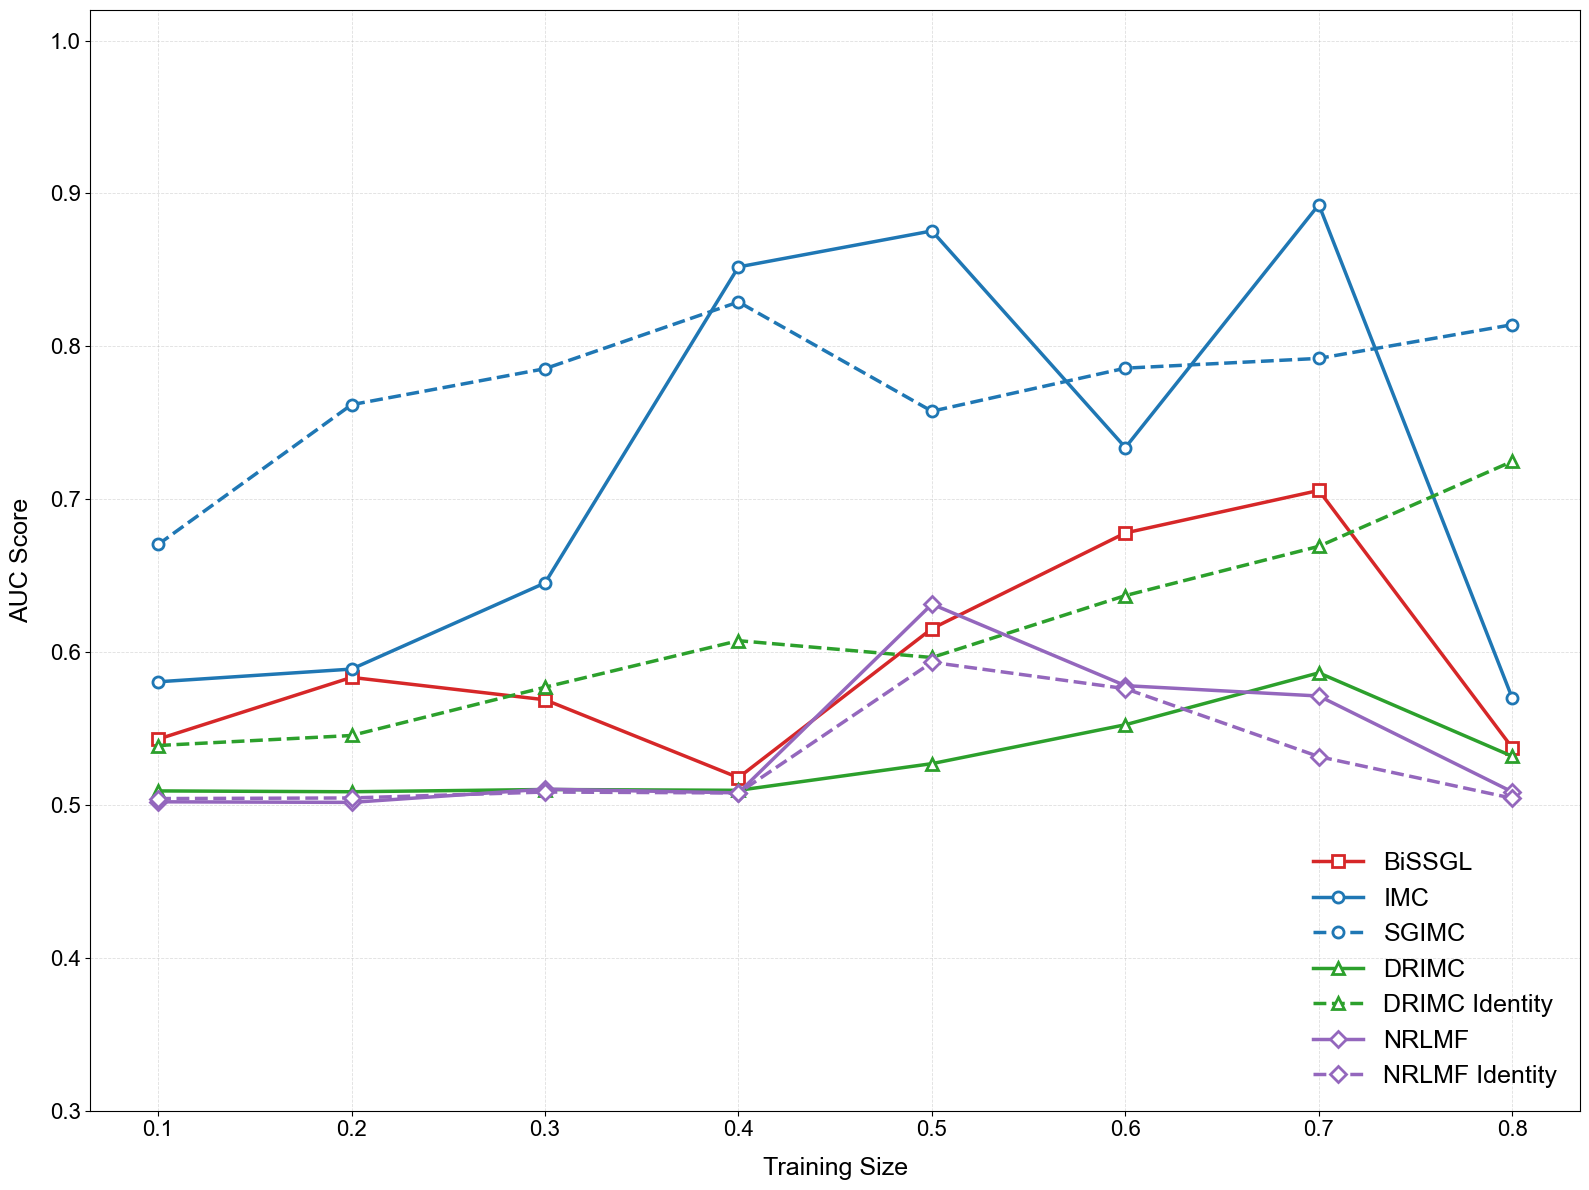

In [174]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BiSSGL",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

plt.plot(
    results_drimc_identity[0],
    results_drimc_identity[1],
    label="DRIMC Identity",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC Identity"],
)

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

plt.plot(
    results_nrlmf_identity[0],
    results_nrlmf_identity[1],
    label="NRLMF Identity",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF Identity"],
)

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

## Case 2: noisy

In [175]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/noisy")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [176]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_bissgl.gz']

In [ ]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [ ]:
results

In [109]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_param="xi",
    target="auc",
)

In [ ]:
results_bissgl

### IMC

In [178]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_imc.gz']

In [179]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [180]:
results

[[{'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 0,
   'val_score': [0.03950462042127971,
    0.5381117569848115,
    0.03636363636363636,
    0.990154189113877,
    0.02,
    0.9992499531220701,
    0.2],
   'test_score': [0.010469087502163774,
    0.5236764692377626,
    0.024294156270518712,
    0.8895700962360198,
    0.1510204081632653,
    0.896355182240888,
    0.013209568011424491]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 1,
   'val_score': [0.02558346675891412,
    0.5408447834557933,
    0.03481012658227848,
    0.886680289801226,
    0.1864406779661017,
    0.8944402704733283,
    0.019197207678883072],
   'test_score': [0.010469087502163774,
    0.5236764692377626,
    0.024294156270518712,
    0.8895700962360198,
    0.1510204081632653,
    0.896355182240888,
    0.013209568011424491]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 2,
   'val_score': [0.011059325589479866,
    0.52728432108027,
    0.026272577996715927

In [181]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="lamb",
    target="auc",
)

In [182]:
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.52579902, 0.54584276, 0.55313316, 0.54503142, 0.558616  ,
        0.597534  , 0.56595476, 0.55320831]])

### SGIMC

In [183]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_sgimc.gz']

In [ ]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [ ]:
results

In [119]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="C_group",
    target="auc",
)

In [ ]:
results_sgimc

### DRIMC

In [185]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_drimc.gz']

In [186]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [187]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005671498743792416,
    0.5116635977007958,
    0.019397651863195507,
    0.8572437112176272,
    0.16593886462882096,
    0.8631764353170439,
    0.010300894551368935],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005678995419160208,
    0.5117355214743605,
    0.019432773109243698,
    0.8612566417716345,
    0.1615720524017467,
    0.8672612801678908,
    0.010338083263481419],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.0056761503697964144,
    0.5117537683475173,
    0.01955085865257596,
    0.8621112473525805,
    0.1615720524017467,
    0.8681232199070604,
    0.010404949381327334],
   'test_d1': 658,
   'test_d2': 409},
  {'train

In [188]:
results_drimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [189]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51177864, 0.51177332, 0.51189541, 0.51180957, 0.51186939,
        0.51182356, 0.51186922, 0.51184738]])

In [190]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.68814164, 0.7525281 , 0.78572343, 0.82288155, 0.86173826,
        0.87237384, 0.89609607, 0.91839774]])

### NRLMF

In [191]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_nrlmf.gz']

In [192]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [193]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.007389338186916924,
    0.5081525515560957,
    0.02753441802252816,
    0.9711291940697804,
    0.044897959183673466,
    0.9796385180740963,
    0.019855595667870037],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.02444216131698628,
    0.5170265976497093,
    0.0546448087431694,
    0.9871437595214209,
    0.04081632653061224,
    0.9958377081145943,
    0.08264462809917356],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.007832957541483372,
    0.5083617757887616,
    0.03379416282642089,
    0.9766283951993461,
    0.044897959183673466,
    0.9851882405879706,
    0.027093596059113302],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'l

In [194]:
results_nrlmf = get_final_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [195]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51702943, 0.51464562, 0.5156485 , 0.51571248, 0.5168662 ,
        0.51645923, 0.51567483, 0.51645464]])

In [196]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.66987035, 0.69751857, 0.78973073, 0.79759176, 0.84064187,
        0.87556088, 0.90131431, 0.9109545 ]])

---

### Plot figures

In [197]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

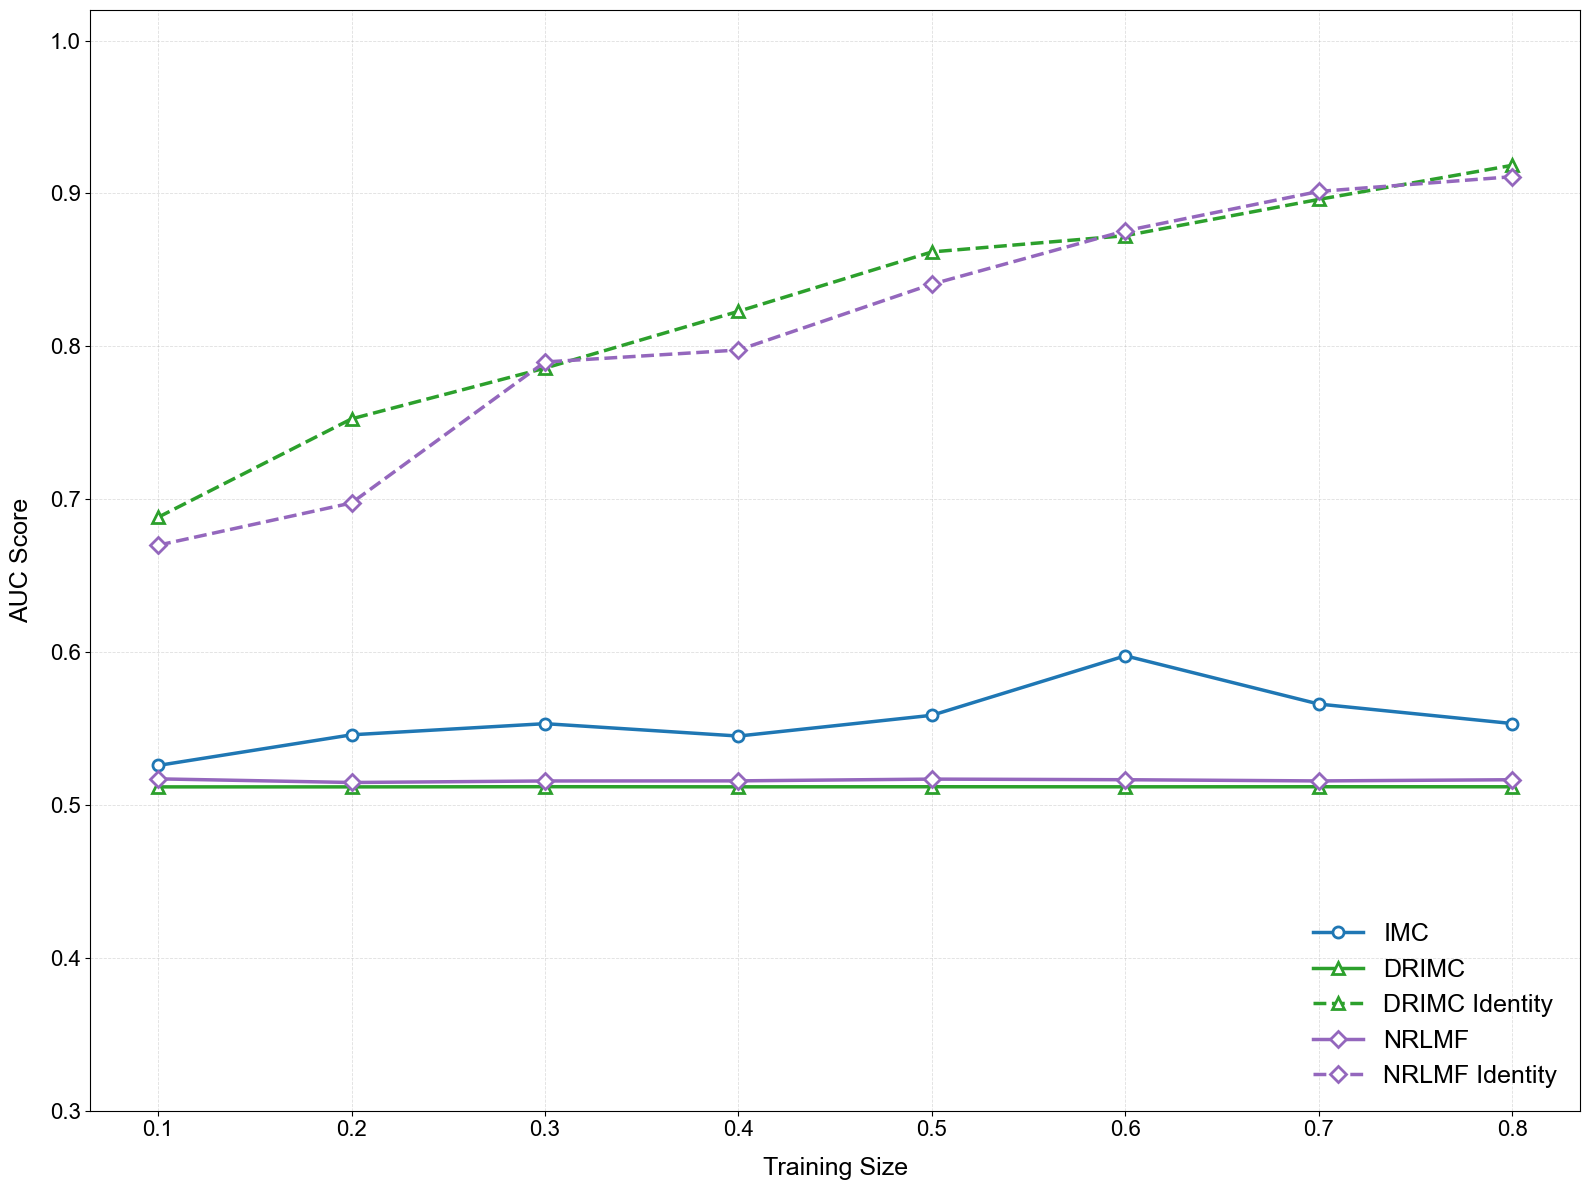

In [199]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
# plt.plot(
#     results_bissgl[0],
#     results_bissgl[1],
#     label="BiSSGL",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["BiSSGL"],
# )

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

# plt.plot(
#     results_sgimc[0],
#     results_sgimc[1],
#     label="SGIMC",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["SGIMC"],
# )

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

plt.plot(
    results_drimc_identity[0],
    results_drimc_identity[1],
    label="DRIMC Identity",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC Identity"],
)

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

plt.plot(
    results_nrlmf_identity[0],
    results_nrlmf_identity[1],
    label="NRLMF Identity",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF Identity"],
)

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

#### Extra plots

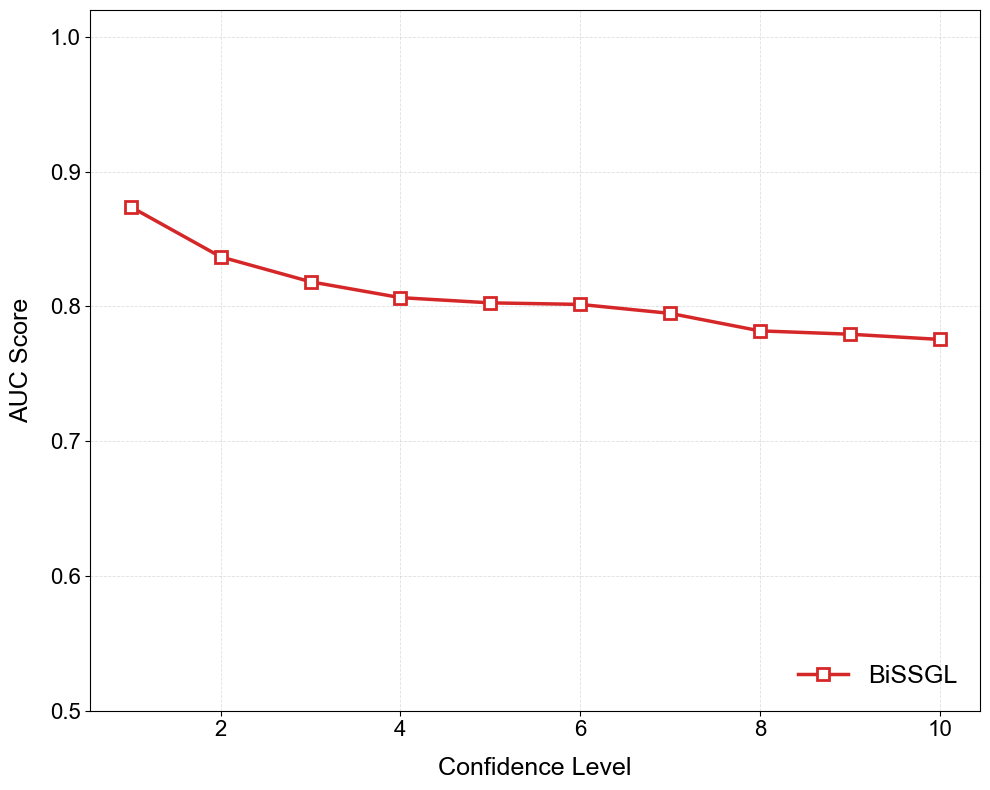

In [ ]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
# plt.plot(
#     results_bissgl_xi[0],
#     results_bissgl_xi[1],
#     label="BiSSGL",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["BiSSGL"],
# )

# Axis limits and labels
plt.ylim(0.5, 1.02)
plt.xlabel("Confidence Level", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_confidence_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

This is the BiSSGL in a random run with just identity matrix:

[{'train_size': 0.81,
  'xi': 10,
  'eta': 0.001,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.5976584761181942,
   **0.9209463761505803,**
   0.6160520607375272,
   0.9934232527031546,
   0.5795918367346938,
   0.9972251387430628,
   0.6574074074074074],
  'test_d1': 658,
  'test_d2': 409}]